# LEC: binary state-pair decoders generalising to held-out tasks (CCGP)

Train a binary classifier to separate two task states (e.g. **A vs B**) on some
tasks, test it on a **held-out task**. The four rewards sit at different towers
in every task, so a decoder that transfers cannot be riding on place — it must
have found a task-invariant (*abstract*) state code. This is CCGP
(Bernardi, Salzman & Fusi 2020).

Binary is a strictly weaker condition than the 4-way leave-one-task-out decoder
in `state_decoding_analysis.py`: a 4-way decoder needs **all four** states
simultaneously separable *and* aligned across tasks, a binary decoder needs
**one** dichotomy aligned. Hence "much more likely to work".

**The pattern across the 6 pairs is the result, not their mean.** Two artifacts
would fake an abstract code. Both live in the **reward windows at the ends of
each leg**, so trimming both ends is the primary control — verified on synthetics
in §1, which is also how these two facts were found:

| artifact | why | tell |
|---|---|---|
| the **tone at reward A** | state A *begins* at reward A and state D *ends* there, so **both** carry the tone | tone-decodable {AB, AC, BD, CD} vs tone-immune **{AD, BC}** |
| **place** | a leg's **destination** tower matching across tasks gives 0.921 transfer | trim the leg ends; `place_control` for corridor cells |

Method + rationale: `CCGP_STATE_PAIRS.md`. All heavy lifting is in
`ccgp_state_pairs.py` (identical copy under `mFC_data/code/`).

In [1]:
import sys
sys.path.insert(0, ".")
from importlib import reload
import numpy as np, pandas as pd, pickle, os
import matplotlib.pyplot as plt
import glm_analysis_v2, ccgp_state_pairs as cc
reload(glm_analysis_v2); reload(cc)
from glm_analysis_v2 import apply_gridmaze_style
apply_gridmaze_style()

REGION = "LEC"
SAVE_DIR = "../data/figures/ccgp_state_pairs"
os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
# ── LEC data ────────────────────────────────────────────────────────────────
Data_folder = "../data/processed_data"
neuron_folder = f"{Data_folder}/neuron_raw_mingyutest"

with open(os.path.join(Data_folder, "data_dic_lec.pkl"), "rb") as f:
    data_dic = pickle.load(f)

neuron_files = [f for f in os.listdir(neuron_folder)
                if f.startswith("Neuron_raw_") and f.endswith(".npy")]
recdays = sorted({"_".join(f[len("Neuron_raw_"):-len(".npy")].split("_")[:-1])
                  for f in neuron_files})
mouse_recdays = [mr for mr in recdays if mr in data_dic and "_sb" not in mr]
print(len(mouse_recdays), "recdays,", len({m[:4] for m in mouse_recdays}), "mice")

24 recdays, 5 mice


## 1. Synthetic controls — the gate

Run **before** looking at real data. Each synthetic flows through the real
pipeline unmodified and validates one specific claim:

| synthetic | expected | validates |
|---|---|---|
| `abstract` | CCGP ≈ 1 on all 6 pairs, even under `leg_anyshare` | the pipeline detects the effect, and the controls don't destroy a real one |
| `place` | **off** chance at `trim_end=0`, **≈ 0.5** at the default | the place control works |
| `tone` | untrimmed {AB,AC,BD,CD} ≫ {AD,BC}; trimmed all ≈ 0.5 | the tone diagnostic works |
| `noise` | ≈ 0.5, covered by the null | no false positives |

**The gate:** `place` must be off chance at `trim_end=0` (else there is no place
signal to control and the test is vacuous) and at chance under the config used.
If not, the controls are broken and nothing below means anything.

These synthetics already caught two design errors the real data could never have
revealed: the place confound runs through the leg's **destination** tower (so the
original source-tower rule controlled the wrong thing), and the tone contaminates
state **D** as well as A (so an "A-pairs vs non-A-pairs" split is wrong).

In [3]:
reload(cc)
synth = cc.run_synthetic_controls(n_shuffles=50)

  place     none          trim=0   ccgp=0.440 null=0.506 tone=0.553 immune=0.213 (n_train=5.0)
  place     none          trim=15  ccgp=0.484 null=0.501 tone=0.492 immune=0.468 (n_train=5.0)
  place     endpoints     trim=0   ccgp=0.309 null=0.503 tone=0.369 immune=0.187 (n_train=3.6)
  place     endpoints     trim=15  ccgp=0.502 null=0.500 tone=0.499 immune=0.507 (n_train=3.6)
  place     leg_anyshare  trim=0   ccgp=0.225 null=0.502 tone=0.229 immune=0.218 (n_train=2.3)
  place     leg_anyshare  trim=15  ccgp=0.518 null=0.501 tone=0.543 immune=0.463 (n_train=2.3)
  abstract  none          trim=15  ccgp=1.000 null=0.503 tone=1.000 immune=1.000 (n_train=5.0)
  abstract  leg_anyshare  trim=15  ccgp=1.000 null=0.490 tone=1.000 immune=1.000 (n_train=2.3)
  tone      none          trim=0   ccgp=0.883 null=0.502 tone=1.000 immune=0.650 (n_train=5.0)
  tone      none          trim=15  ccgp=0.491 null=0.501 tone=0.505 immune=0.463 (n_train=5.0)
  noise     none          trim=15  ccgp=0.478 null

In [4]:
# Data cost of each place rule on the REAL task configurations.
cfg0 = cc.CCGPConfig()
tasks_by_recday = [t for t in (cc.build_task_state_matrices(data_dic, mr, cfg0)
                               for mr in mouse_recdays) if t]
pd.DataFrame([cc.place_control_cost(tasks_by_recday, r) for r in cc.PLACE_RULES])

,rule,mean_kept,median_kept,frac_ge2,frac_zero,n_folds
0,none,4.383333,5.0,1.000000,0.000000,720
1,source,3.488889,4.0,0.947222,0.018056,720
2,endpoints,3.008333,3.0,0.877778,0.033333,720
3,leg_exact,4.261111,4.0,0.991667,0.000000,720
4,leg_anyshare,1.488889,1.0,0.462500,0.184722,720


## 2. The headline: CCGP per state pair

For each held-out task × each of the 6 pairs: train on the other tasks (minus
those failing the place control), test on the held-out task.

The null is the **role-permutation null**: each training task independently gets
a random ordered pair of states to play the roles of (i,j), refit, test on the
true (i,j). Within-task geometry and n are preserved exactly; only the
cross-task correspondence is destroyed — which is what "abstract" claims.

(Chance is 0.5, but testing against 0.5 with a binomial is wrong here: samples
within a task are correlated and n is small, so the *variance* is what needs
calibrating. See `CCGP_STATE_PAIRS.md` §4.2.1 for the seductive null we do
**not** use and why it is algebraically degenerate.)

In [5]:
config = cc.CCGPConfig()
print(config)

# ~10-25 min. The role-permutation null dominates: a real decoder fits in ~2 ms because
# the states are separable, but a role-permuted one runs to max_iter (~47 ms) because
# scrambled labels are not. Do NOT lower max_iter to speed this up — that under-converges
# the NULL only, weakening the comparison decoder and biasing the test anti-conservatively.
# Parallelise instead; it changes nothing statistically.
res = cc.run_ccgp_batch(data_dic, config, mouse_recdays=mouse_recdays, n_jobs=4)
ccgp, transfer = res["ccgp"], res["transfer"]
ccgp.to_pickle(f"{SAVE_DIR}/ccgp_{REGION}.pkl")
transfer.to_pickle(f"{SAVE_DIR}/transfer_{REGION}.pkl")
print(ccgp.shape)

CCGPConfig(source='norm', num_bins_per_state=90, num_task_states=4, trim_start_bins=15, trim_end_bins=15, aggregator='mean', zscore='per_task', min_trials=8, min_neurons=12, min_train_tasks=2, clf='linear_svc', C=1.0, max_iter=5000, place_control='endpoints', n_shuffles=200, random_state=0)


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  1.7min
[Parallel(n_jobs=4)]: Done  22 out of  24 | elapsed: 10.2min remaining:   55.5s
[Parallel(n_jobs=4)]: Done  24 out of  24 | elapsed: 13.0min finished


  ah08_20250613_20250615: 4 tasks, 151 neurons, CCGP 0.368 (null 0.500, ceiling 0.857)
  ah08_20250616_20250617: 5 tasks, 164 neurons, CCGP 0.461 (null 0.501, ceiling 0.853)
  ah08_20250618_20250619: 5 tasks, 183 neurons, CCGP 0.355 (null 0.501, ceiling 0.862)
  ah08_20250620_20250623: 4 tasks, 108 neurons, CCGP 0.535 (null 0.502, ceiling 0.829)
  ah10_20250613_20250615: 6 tasks, 139 neurons, CCGP 0.411 (null 0.503, ceiling 0.937)
  ah10_20250616_20250617: 6 tasks, 154 neurons, CCGP 0.365 (null 0.499, ceiling 0.947)
  ah10_20250618_20250619: 5 tasks, 162 neurons, CCGP 0.345 (null 0.493, ceiling 0.951)
  ah10_20250620_20250623: 6 tasks, 153 neurons, CCGP 0.405 (null 0.502, ceiling 0.933)
  ah10_20250624_20250625: 6 tasks, 164 neurons, CCGP 0.490 (null 0.501, ceiling 0.926)
  ly05_20250613_20250615: 4 tasks, 117 neurons, CCGP 0.445 (null 0.497, ceiling 0.741)
  ly05_20250616_20250617: 4 tasks, 116 neurons, CCGP 0.374 (null 0.505, ceiling 0.861)
  ly05_20250618_20250619: 1 tasks, 91 neuro

In [6]:
display(cc.summarise_pairs(ccgp).round(3))
pd.Series(cc.test_ccgp(ccgp)).to_frame("value")

,pair,mean,sem,count,null,null_std,ceiling,lag,tone_available
0,AB,0.424,0.014,103,0.500,0.143,0.841,1,True
1,AC,0.438,0.013,101,0.500,0.138,0.826,2,True
2,AD,0.425,0.014,107,0.500,0.150,0.846,1,False
3,BC,0.412,0.014,105,0.500,0.149,0.860,1,False
4,BD,0.443,0.013,101,0.501,0.134,0.808,2,True
5,CD,0.396,0.013,115,0.500,0.154,0.864,1,True


,value
n_recdays,2.300000e+01
n_mice,5.000000e+00
ccgp_mean,4.259676e-01
null_mean,5.002579e-01
ceiling_mean,8.296098e-01
p_recday,3.337860e-06
n_mice_used,5.000000e+00
ccgp_mouse_mean,4.263032e-01
p_mouse,6.250000e-02
ccgp_tone_mean,4.281812e-01


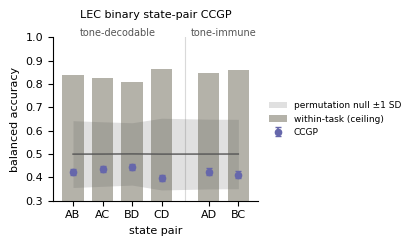

In [7]:
cc.plot_pair_ccgp(ccgp, region=REGION, out_path=f"{SAVE_DIR}/pair_ccgp_{REGION}.pdf")
plt.show()

## 2b. Per-mouse breakdown

Recdays within a mouse are **not** independent (5 LEC mice / 23 recdays; 7 PFC
mice / 23), so the per-mouse view is the honest one: it shows whether the effect
is a consistent property of every animal or is carried by one or two.

`plot_by_mouse` — one panel per mouse, all 6 pairs, with the within-task ceiling
as bars and the role-permutation null as a band. Small dots are individual
recdays.

`plot_mouse_summary` — the compact version: one point per mouse (dots = recdays),
with its null and ceiling. Pass both regions to compare LEC and PFC side by side.

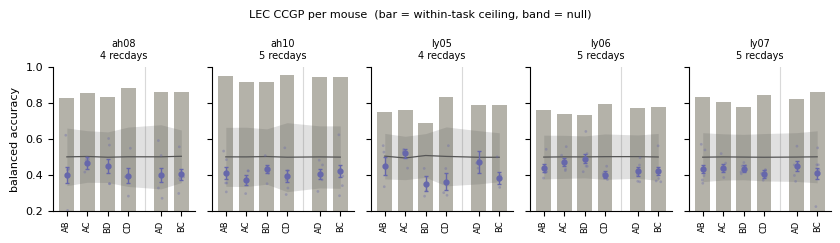

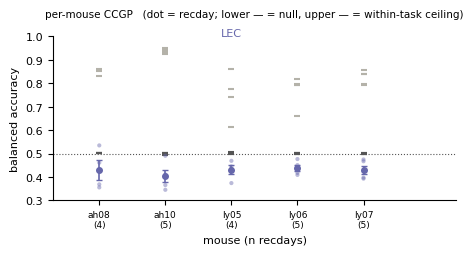

,n_recdays,ccgp,null,ceiling,recdays_below_null
mouse,,,,,
ah08,4,0.430,0.501,0.850,3
ah10,5,0.403,0.500,0.939,5
ly05,4,0.431,0.501,0.748,4
ly06,5,0.437,0.501,0.772,5
ly07,5,0.431,0.499,0.826,5


In [8]:
cc.plot_by_mouse(ccgp, region=REGION, out_path=f"{SAVE_DIR}/by_mouse_{REGION}.pdf")
plt.show()

cc.plot_mouse_summary({REGION: ccgp},
                      out_path=f"{SAVE_DIR}/mouse_summary_{REGION}.pdf")
plt.show()

rec = cc.summarise_recdays(ccgp)
per_mouse = rec.groupby("mouse").agg(n_recdays=("mouse_recday", "nunique"),
                                      ccgp=("ccgp", "mean"), null=("null", "mean"),
                                      ceiling=("ceiling", "mean"))
per_mouse["recdays_below_null"] = rec.assign(b=rec.ccgp < rec.null).groupby("mouse")["b"].sum()
per_mouse.round(3)

## 3. The tone control

The tone plays at reward A. State A **begins** at reward A and state D **ends**
there, so **both A and D carry the tone**. A tone-driven decoder separates
{A, D} from {B, C}, so it can discriminate a pair only if *exactly one* of its
states carries the tone:

- **tone-decodable**: AB, AC, BD, CD
- **tone-immune**: AD (both carry it), BC (neither does)

**If CCGP is high only on {AB, AC, BD, CD} while {AD, BC} sit at null, it is the
tone.** Only 2 of 6 pairs are immune, so that grouping alone is weak — the trim
sweep below carries the weight. A tone response dies with trimming; an abstract
state code survives.

In [ ]:
from dataclasses import replace
rows = []
for trim in [0, 5, 10, 15, 25, 35]:
    # Trim symmetrically: the tone is at A's START and D's END, so both are needed.
    r = cc.run_ccgp_batch(data_dic, replace(config, trim_start_bins=trim, trim_end_bins=trim),
                          mouse_recdays=mouse_recdays, verbose=False, n_jobs=4,
                          with_transfer=False, with_ceiling=False)["ccgp"]
    rows.append({"trim": trim,
                 "ccgp_tone": r.loc[r["tone_available"], "acc"].mean(),
                 "ccgp_immune": r.loc[~r["tone_available"], "acc"].mean(),
                 "null": r["null_mean"].mean()})
    print(rows[-1])
sweep = pd.DataFrame(rows)
sweep.to_pickle(f"{SAVE_DIR}/tone_sweep_{REGION}.pkl")
cc.plot_tone_diagnostic(sweep, region=REGION, out_path=f"{SAVE_DIR}/tone_{REGION}.pdf")
plt.show()

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  1.5min
[Parallel(n_jobs=4)]: Done  22 out of  24 | elapsed:  8.5min remaining:   46.6s
[Parallel(n_jobs=4)]: Done  24 out of  24 | elapsed: 10.4min finished


{'trim': 0, 'ccgp_tone': np.float64(0.4109110390978518), 'ccgp_immune': np.float64(0.4101510435553559), 'null': np.float64(0.4997504187250614)}


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done  22 out of  24 | elapsed:  9.3min remaining:   50.7s
[Parallel(n_jobs=4)]: Done  24 out of  24 | elapsed: 11.7min finished


{'trim': 5, 'ccgp_tone': np.float64(0.4147879061142305), 'ccgp_immune': np.float64(0.41923657697700806), 'null': np.float64(0.49992145206460287)}


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done  22 out of  24 | elapsed:  9.9min remaining:   53.8s


## 3b. Leg-window sweep — where along the leg does state info live?

The headline uses the **mid-leg** window (bins 15–75) to remove the tone and
reward-tower place. Here we re-run the decoders over several windows of the
90-bin state (`post_reward` 0–15 = the tone window in state A; `early` 0–30;
`mid` 15–75; `late` 60–90; `full` 0–90). These **relax** the tone control
(place stays filtered). Split into A-pairs {AB,AC,AD} (which can ride the tone,
and the tone is task-invariant so it *generalises*) vs non-A pairs.

**Read:** A-pairs lifting above null in the early/post-reward windows while non-A
stay at chance ⇒ the tone (validates the mid-leg headline). A uniform lift that
survives ⇒ a genuine early-progress state code. The per-window within-task
ceiling shows where state info sits within a task.

In [ ]:
windows = cc.run_ccgp_windows(data_dic, config, mouse_recdays=mouse_recdays,
                             n_shuffles=50, n_jobs=4)
windows.to_pickle(f"{SAVE_DIR}/windows_{REGION}.pkl")
import numpy as np
windows["grp"] = np.where(windows["pair"].isin(cc.TONE_PAIRS), "A-pair (tone)", "non-A")
display(windows.groupby(["window", "grp"])["acc"].mean().unstack().reindex(cc._WINDOW_ORDER).round(3))
cc.plot_ccgp_windows(windows, region=REGION, out_path=f"{SAVE_DIR}/ccgp_windows_{REGION}.pdf")
plt.show()

## 4. The place control, measured rather than assumed

CCGP split by whether the decoded legs shared a tower with the test task. Note
the expected sign is **negative**: on the synthetic, a pure place code transfers
*below* chance (0.407), because place remaps and towers get systematically
mis-assigned across tasks. Place mainly **masks** a real effect rather than
faking one — it only fakes a positive on folds where the leg's **destination**
tower happens to match (0.921 when it does, 0.404 when it does not).

Then `leg_anyshare` as the robustness check: the only rule that also breaks the
cross case (train's source == test's destination), at the cost of 64% of the
training data.

In [ ]:
cc.plot_place_contrast(ccgp, region=REGION, out_path=f"{SAVE_DIR}/place_{REGION}.pdf")
plt.show()

strict = cc.run_ccgp_batch(data_dic, replace(config, place_control="leg_anyshare"),
                           mouse_recdays=mouse_recdays, verbose=False, n_jobs=4,
                           with_transfer=False)["ccgp"]
strict.to_pickle(f"{SAVE_DIR}/ccgp_strict_{REGION}.pkl")
print("strict place control (leg_anyshare):")
display(cc.summarise_pairs(strict).round(3))
pd.Series(cc.test_ccgp(strict)).to_frame("value")

## 5. Is the code A-anchored, or rotation-symmetric?

A is the only reward paired with a tone — that is what licenses "A" meaning the
same thing across tasks. Whether the mouse *uses* it is open, so we test it.

**Descriptive only, not a null** (§4.2.1). Canonical (i<j) orientation only: the
flipped orientation is just `1 - acc`, so averaging both would force every cell
to 0.5.

- **diagonal** = CCGP;
- **off-diagonal** structure = whether a decoder trained on one pair transfers to
  others at a predictable rotation. If A is not functionally anchored, the matrix
  is rotation-symmetric and the diagonal is not special.

Also: **adjacent** (AB/BC/CD/AD — D→A is adjacent) vs **opposite** (AC/BD). A
phase/ramp code predicts lag-dependence; a discrete state-identity code predicts
uniform accuracy across all 6.

In [ ]:
cc.plot_transfer_matrix(transfer, region=REGION, out_path=f"{SAVE_DIR}/transfer_{REGION}.pdf")
plt.show()
display(cc.transfer_matrix(transfer).round(3))
print("\nby cyclic lag (1 = adjacent, 2 = opposite):")
display(ccgp.groupby("lag")["acc"].agg(["mean", "sem", "count"]).round(3))

## 6. Binary vs 4-way — the literal test of the claim

Stefano's argument predicts binary should work where 4-way does not. Each is
plotted relative to its own chance level (0.5 vs 0.25).

In [ ]:
import state_decoding_analysis as sda
reload(sda)
with open(os.path.join(Data_folder, "session_inds_dic.pkl"), "rb") as f:
    session_inds_dic = pickle.load(f)
with open(os.path.join(Data_folder, "tasks_dic.pkl"), "rb") as f:
    tasks_dic = pickle.load(f)

rows = []
for mr in mouse_recdays:
    try:
        r = sda.decode_states_loo_cv(data_dic, session_inds_dic, tasks_dic, mr)
    except Exception as e:
        print(mr, "failed:", e); continue
    if r is None:
        continue
    for fold in r["task_results"]:
        rows.append({"mouse_recday": mr, "acc": fold["fold_accuracy"]})
fourway = pd.DataFrame(rows)
fourway.to_pickle(f"{SAVE_DIR}/fourway_{REGION}.pkl")
cc.plot_binary_vs_fourway(ccgp, fourway, region=REGION,
                          out_path=f"{SAVE_DIR}/binary_vs_fourway_{REGION}.pdf")
plt.show()

## 7. How to read this

| pattern | reading |
|---|---|
| all 6 pairs > null; survives trimming; shared-tower ≈ no-shared-tower | **abstract state code** |
| only A-pairs > null; dies with trimming | **tone response**, not state |
| only shared-tower folds > null | **place** leaking through |
| adjacent ≠ opposite; transfer matrix rotation-symmetric | **task-phase / ramp**, not discrete state identity |
| all ≈ null, ceiling high | state is coded, **not abstractly** |
| all ≈ null, ceiling at chance | no state code recoverable at this n |